# Accessible PlantUML Sequence Diagrams

This notebook demonstrates how to create an accessibility-aware sequence diagram in PlantUML from Python.

## What this diagram is used for

Sequence diagrams represent interactions between participants in chronological order. Their top-to-bottom interaction structure can support sequential interpretation and verbal explanation.

## How to make it more accessible

Use meaningful participant names, describe actions explicitly, keep the interaction order clear, and avoid overly dense bidirectional communication. The PlantUML source should remain readable as text and should be accompanied by a structured semantic explanation.

## Setup

These notebooks use **Python to write PlantUML source code and call PlantUML locally** to render the diagram.

PlantUML must therefore be available on your system. A local PlantUML installation requires Java, and some diagram types may also require Graphviz.

You can use PlantUML in either of these ways:

1. **Install the PlantUML command-line tool** using the package manager available on your operating system.
2. **Download `plantuml.jar`** from the PlantUML website and run it with Java.

After installation, verify that PlantUML is available by running:

```bash
plantuml -version
```

If you use a downloaded `plantuml.jar` instead of a `plantuml` command, set the `PLANTUML_JAR` environment variable to the path of the JAR file before running the notebook.

The Python helper below supports both approaches.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess

from IPython.display import Image, display


def render_plantuml(source, filename):
    """Save PlantUML source, render it as PNG, and display it."""
    source_path = Path(f"{filename}.puml")
    source_path.write_text(source, encoding="utf-8")

    plantuml_executable = shutil.which("plantuml")
    plantuml_jar = os.environ.get("PLANTUML_JAR")

    if plantuml_executable:
        command = [
            plantuml_executable,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    elif plantuml_jar:
        command = [
            "java",
            "-jar",
            plantuml_jar,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    else:
        raise RuntimeError(
            "PlantUML was not found. Install the 'plantuml' command "
            "or set PLANTUML_JAR to the path of plantuml.jar."
        )

    result = subprocess.run(command, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError("PlantUML rendering failed:\n" + result.stderr)

    image_path = source_path.with_suffix(".png")
    if not image_path.exists():
        raise FileNotFoundError(f"Rendered image was not created: {image_path}")

    display(Image(filename=str(image_path)))
    return image_path


## Accessible example

The example below creates an accessibility-aware sequence diagram also presented in the Guidelines document.

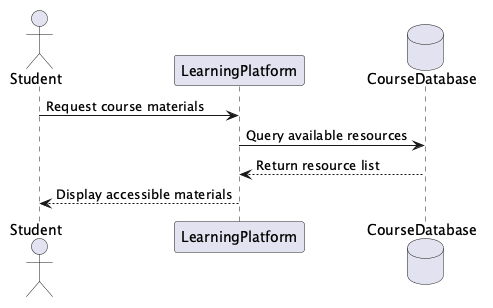

PosixPath('accessible_sequence_diagram.png')

In [ ]:
sequence_source = """@startuml
skinparam dpi 300
actor Student
participant LearningPlatform
database CourseDatabase

Student -> LearningPlatform : Request course materials
LearningPlatform -> CourseDatabase : Query available resources
CourseDatabase --> LearningPlatform : Return resource list
LearningPlatform --> Student : Display accessible materials
@enduml
"""

render_plantuml(sequence_source, "accessible_sequence_diagram")

## Accessible description

Sequence diagram showing Student, LearningPlatform, and CourseDatabase. The Student requests course materials from the LearningPlatform. The platform queries the CourseDatabase, the database returns a resource list, and the platform displays accessible materials to the Student. The interaction represents a client-service-database flow for retrieving educational resources.

## Reusable accessible template

Replace the placeholder participant names and interaction labels with meaningful names from your own system.

In [ ]:
sequence_template = """@startuml
actor UserRole
participant ServiceName
database DataStore

UserRole -> ServiceName : Describe the request explicitly
ServiceName -> DataStore : Describe the data operation
DataStore --> ServiceName : Describe the returned information
ServiceName --> UserRole : Describe the final response
@enduml
"""

render_plantuml(sequence_template, "sequence_diagram_template")

## Accessible description template

After replacing the placeholder source with your own sequence diagram, add a concise textual description that:

- identifies the diagram type and purpose,
- names the important entities, classes, actions, states, or nodes,
- explains the relationships or interaction order,
- describes decision or transition logic where relevant,
- and states the key structural takeaway.

Do not rely on spatial wording alone. The description should communicate the important relationships encoded by the diagram.
